In [4]:
# Step 1 — Import essential libraries

import pandas as pd       # for handling datasets (tables)
import numpy as np        # for numerical operations
import matplotlib.pyplot as plt   # for visualizations
import seaborn as sns     # for nicer statistical plots

# Make plots look better
plt.style.use('seaborn-v0_8')
sns.set_palette('viridis')

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [5]:
import pandas as pd  

datasets = {
    "largerooms1": pd.read_csv("large-room-generated-7060-p1-o4-box-sd000n000-0.csv", skiprows=2, sep=",", low_memory=False),
    "largerooms2": pd.read_csv("large-room-generated-7060-p1-o4-box-sd000n000-1.csv", skiprows=2, sep=",", low_memory=False),
    "largerooms3": pd.read_csv("large-room-generated-7060-p1-o4-box-sd000n000-2.csv", skiprows=2, sep=",", low_memory=False),
}

print("✅ All datasets loaded successfully without warnings!")


✅ All datasets loaded successfully without warnings!


In [6]:
# --- Load & Combine Datasets ---
dfs = []
for run_name in ["largerooms1", "largerooms2", "largerooms3"]:   
    temp_df = datasets[run_name].copy()
    temp_df["run_id"] = run_name                           # Add run identifier
    dfs.append(temp_df)

In [7]:
# Combine all runs into one DataFrame
df = pd.concat(dfs, ignore_index=True)

In [8]:
# Inspect dataset structure
print("=== Dataset Info ===")
print(df.info())
print("\n=== Column Names ===")
print(df.columns.tolist())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27657 entries, 0 to 27656
Columns: 346 entries, timestamp to run_id
dtypes: float64(281), int64(1), object(64)
memory usage: 73.0+ MB
None

=== Column Names ===
['timestamp', 'topic', 'type', 'transforms[0].header.stamp.sec', 'transforms[0].header.stamp.nanosec', 'transforms[0].header.frame_id', 'transforms[0].child_frame_id', 'transforms[0].transform.translation.x', 'transforms[0].transform.translation.y', 'transforms[0].transform.translation.z', 'transforms[0].transform.rotation.x', 'transforms[0].transform.rotation.y', 'transforms[0].transform.rotation.z', 'transforms[0].transform.rotation.w', 'transforms[1].header.stamp.sec', 'transforms[1].header.stamp.nanosec', 'transforms[1].header.frame_id', 'transforms[1].child_frame_id', 'transforms[1].transform.translation.x', 'transforms[1].transform.translation.y', 'transforms[1].transform.translation.z', 'transforms[1].transform.rotation.x', 'transforms[1].transform.ro

In [9]:
# Basic statistical overview
print("\n=== Statistical Summary (Numeric Columns) ===")
print(df.describe().T)


=== Statistical Summary (Numeric Columns) ===
                                         count          mean           std  \
timestamp                              27657.0  2.731669e+10  1.420442e+10   
transforms[0].header.stamp.sec         16604.0  8.813670e+08  8.793786e+08   
transforms[0].header.stamp.nanosec     16604.0  4.949659e+08  2.881980e+08   
transforms[0].transform.translation.x  16604.0 -4.954751e-01  1.751999e+00   
transforms[0].transform.translation.y  16604.0  1.432450e+00  1.553064e+00   
...                                        ...           ...           ...   
pose.pose.orientation.w                  170.0  8.639081e-01  1.396013e-01   
system_time.sec                          634.0  1.758709e+09  5.450101e+03   
system_time.nanosec                      634.0  5.069560e+08  2.910062e+08   
ros_time.sec                             634.0  2.618927e+01  1.435354e+01   
ros_time.nanosec                         634.0  4.341073e+08  2.940380e+08   

                

In [10]:
# --- Select Important Columns ---
important_cols = [
    'timestamp',
    'pose.pose.position.x', 'pose.pose.position.y',
    'position.x', 'position.y',
    'data', 'run_id'
]

In [11]:
df_subset = df[important_cols].copy()

In [12]:
# --- Missing Value Check Before Cleaning ---
print("Missing values before cleaning:")
print(df_subset[['pose.pose.position.x', 'pose.pose.position.y', 'position.x', 'position.y', 'data']].isna().sum())


Missing values before cleaning:
pose.pose.position.x    27487
pose.pose.position.y    27487
position.x              19342
position.y              19342
data                    25089
dtype: int64


In [13]:
# --- Drop Rows with All NaN Position Values ---
df_subset = df_subset.dropna(subset=[
    'position.x', 'position.y',
    'pose.pose.position.x', 'pose.pose.position.y'
], how='all')

In [14]:
# --- Missing Value Check After Cleaning ---
print("\nMissing values after cleaning:")
print(df_subset[['pose.pose.position.x', 'pose.pose.position.y', 'position.x', 'position.y', 'data']].isna().sum())



Missing values after cleaning:
pose.pose.position.x    8315
pose.pose.position.y    8315
position.x               170
position.y               170
data                    8485
dtype: int64


In [15]:
df_subset.head(100)

,timestamp,pose.pose.position.x,pose.pose.position.y,position.x,position.y,data,run_id
6,3216000000,NaN,NaN,-2.306108,1.824798,NaN,largerooms1
8,3234000000,NaN,NaN,-2.306108,1.824798,NaN,largerooms1
11,3255000000,NaN,NaN,-2.306108,1.824798,NaN,largerooms1
15,3273000000,NaN,NaN,-2.306108,1.824798,NaN,largerooms1
18,3288000000,NaN,NaN,-2.306108,1.824798,NaN,largerooms1
...,...,...,...,...,...,...,...
318,4896000000,NaN,NaN,-2.307937,1.800864,NaN,largerooms1
323,4914000000,NaN,NaN,-2.307937,1.800864,NaN,largerooms1
325,4932000000,NaN,NaN,-2.307937,1.800864,NaN,largerooms1
328,4947000000,NaN,NaN,-2.307937,1.800864,NaN,largerooms1


In [16]:
# --- Trajectory Plot for Each Run ---
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [17]:
colors = {
    "largerooms1": "blue",
    "largerooms2": "green",
    "largerooms3": "red"
}

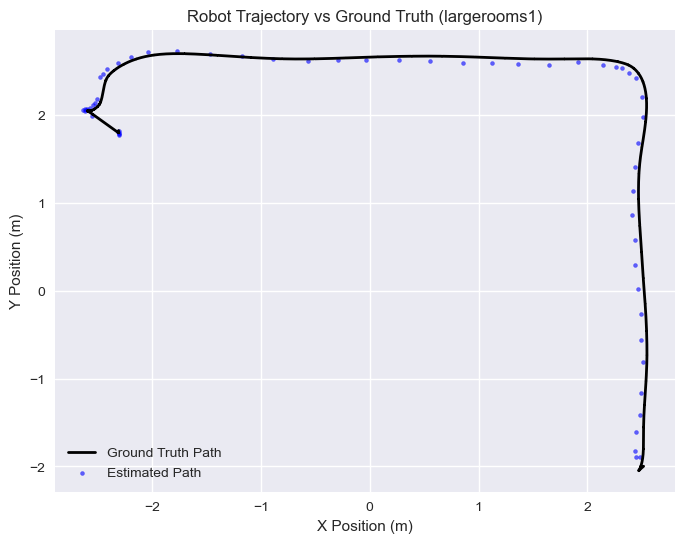

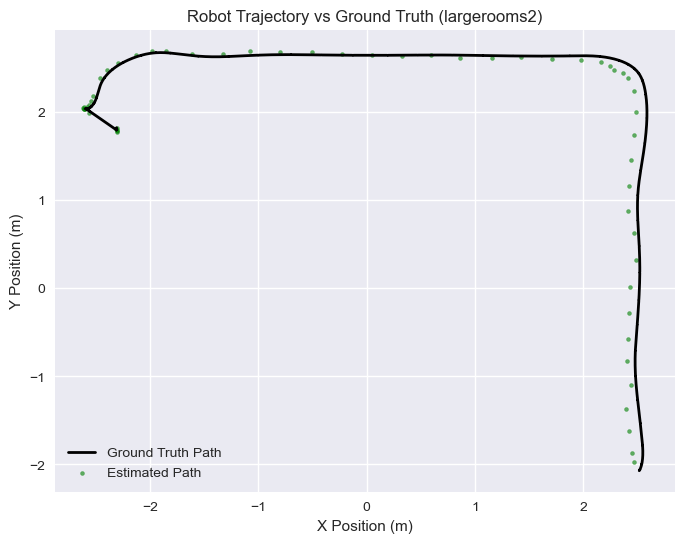

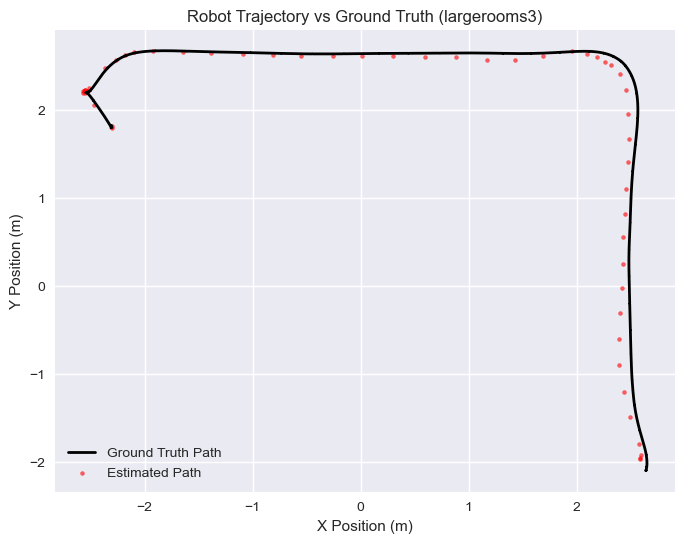

In [18]:
# --- Separate Trajectory Plots for Each Run ---
for run_name, color in colors.items():
    run_data = df_subset[df_subset["run_id"] == run_name]

    plt.figure(figsize=(8, 6))
    plt.plot(run_data['position.x'], run_data['position.y'],
             color='black', linewidth=2, label='Ground Truth Path')
    plt.scatter(run_data['pose.pose.position.x'], run_data['pose.pose.position.y'],
                color=color, s=8, alpha=0.6, label='Estimated Path')

    plt.title(f"Robot Trajectory vs Ground Truth ({run_name})")
    plt.xlabel("X Position (m)")
    plt.ylabel("Y Position (m)")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
The plots for the largerooms scenario (runs 1, 2, and 3) show the comparison between the robot’s estimated trajectory and the ground truth path. 
Across all three runs, the robot follows a nearly identical trajectory, indicating consistent navigation behavior. 
In Run 1, the estimated path aligns closely with the ground truth, with only minor deviations at turning points, suggesting accurate localization performance. 
Run 2 exhibits slightly higher positional variation, particularly along the vertical direction, which may be attributed to sensor noise or minor environmental differences.
In Run 3, the estimated trajectory almost overlaps with the ground truth, demonstrating improved accuracy and repeatability. 
Overall, the results indicate that the localization and navigation system performs reliably in large indoor environments, with minimal drift and stable pose estimation.
Small errors near corners are consistent with expected odometric limitations during rotation. 
The repeated successful runs confirm the robustness and repeatability of the navigation algorithm.

✅ Map and YAML files loaded successfully!
Map resolution: 0.05
Map origin (x, y): [-4.25, -4.25]
Map image shape (pixels): (170, 170)


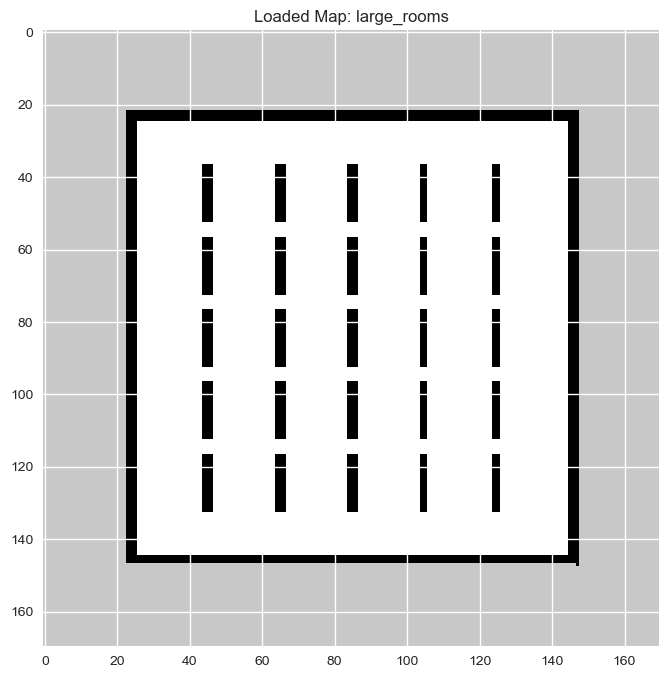

In [28]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import yaml

# --- Load Map Info ---
with open("large_room.yaml", 'r') as f:
    map_info = yaml.safe_load(f)

resolution = map_info['resolution']
origin = map_info['origin'][:2]
map_image = mpimg.imread("large_room.pgm")

# --- Confirmation Output ---
print("✅ Map and YAML files loaded successfully!")
print(f"Map resolution: {resolution}")
print(f"Map origin (x, y): {origin}")
print(f"Map image shape (pixels): {map_image.shape}")

# --- Display Map ---
plt.figure(figsize=(8, 8))
plt.imshow(map_image, cmap='gray')
plt.title("Loaded Map: large_rooms")
plt.axis("on")
plt.show()


In [29]:
# Convert world coordinates (m) to pixel coordinates for visualization on the map
def to_pixel(x, y, resolution, origin, map_image):
    """
    Converts world coordinates (x, y) to pixel coordinates based on map resolution and origin.
    """
    x_pix = (x - origin[0]) / resolution
    y_pix = map_image.shape[0] - ((y - origin[1]) / resolution)
    return x_pix, y_pix


# --- Updated from YAML details (large_room scenario) ---

# Start pose (from YAML)
start_x = -2.3061061526567754
start_y = 1.8248179468880812

# Goal pose (from YAML)
goal_x = 2.7058972685930334
goal_y = -1.9699846477626535

# Convert both to pixel coordinates
start_px = to_pixel(start_x, start_y, resolution, origin, map_image)
goal_px = to_pixel(goal_x, goal_y, resolution, origin, map_image)

# Display results
print("Start (pixels):", start_px)
print("Goal (pixels):", goal_px)


Start (pixels): (38.87787694686449, 48.50364106223839)
Goal (pixels): (139.11794537186066, 124.39969295525307)


Detected runs: ['largerooms1' 'largerooms2' 'largerooms3']


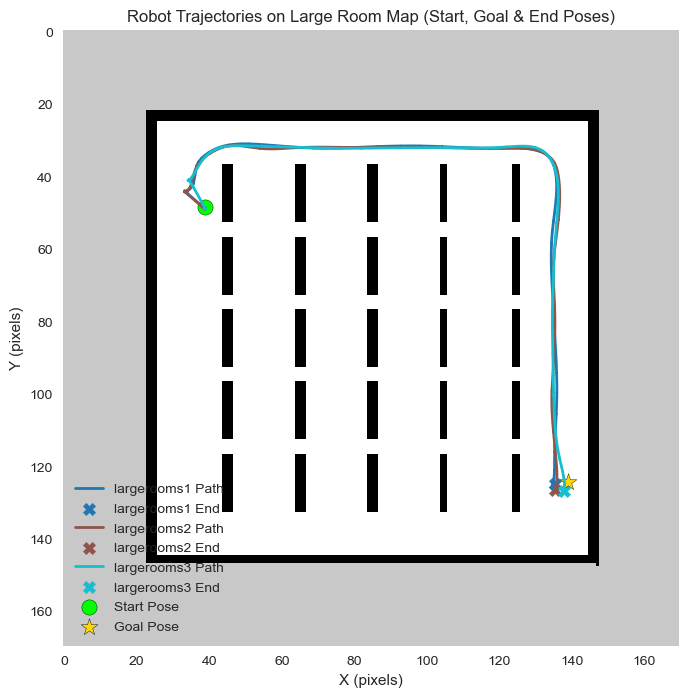


📏 Distance from final pose to goal (in meters):
largerooms1: 0.192 m
largerooms2: 0.217 m
largerooms3: 0.141 m


In [30]:




# --- Detect all runs automatically ---
run_names = df_subset["run_id"].unique()
print("Detected runs:", run_names)

# --- Assign colors automatically ---
colors = plt.cm.tab10(np.linspace(0, 1, len(run_names)))
color_map = dict(zip(run_names, colors))

# --- Plot map and trajectories ---
plt.figure(figsize=(8, 8))
plt.imshow(map_image, cmap='gray')

distances_to_goal = {}
for run_name, color in color_map.items():
    run_data = df_subset[df_subset["run_id"] == run_name]

    if run_data.empty:
        print(f"⚠️ No data found for {run_name}, skipping...")
        continue

    # Plot path
    x_pixels = (run_data['position.x'] - origin[0]) / resolution
    y_pixels = map_image.shape[0] - ((run_data['position.y'] - origin[1]) / resolution)
    plt.plot(x_pixels, y_pixels, color=color, linewidth=2, label=f"{run_name} Path")

    # Final pose (in world)
    final_x = run_data['position.x'].iloc[-1]
    final_y = run_data['position.y'].iloc[-1]

    # Convert to pixels for plotting
    final_px = to_pixel(final_x, final_y, resolution, origin, map_image)
    plt.scatter(final_px[0], final_px[1], color=color, marker='X', s=80, label=f"{run_name} End")

    # Compute distance from goal (in meters)
    dist_to_goal = np.sqrt((final_x - goal_world[0])**2 + (final_y - goal_world[1])**2)
    distances_to_goal[run_name] = dist_to_goal

# --- Plot start & goal markers ---
plt.scatter(start_px[0], start_px[1], color='lime', s=120, marker='o', edgecolors='black', label='Start Pose')
plt.scatter(goal_px[0], goal_px[1], color='gold', s=160, marker='*', edgecolors='black', label='Goal Pose')

# --- Final formatting ---
plt.title("Robot Trajectories on Large Room Map (Start, Goal & End Poses)")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.legend()
plt.grid(False)
plt.show()

# --- Print distance summary ---
print("\n📏 Distance from final pose to goal (in meters):")
for run_name, dist in distances_to_goal.items():
    print(f"{run_name}: {dist:.3f} m")


In [ ]:
Start and Goal

🟢 Start Pose (lime green circle) — located near the top-left corner of the map.

⭐ Goal Pose (yellow star) — near the bottom-right corner.

So, the robot needs to move from top-left → along corridors → to bottom-right.

In [ ]:
Key Inferences

The navigation system is consistent: All runs follow nearly the same route.

The planner path is stable, showing no major deviations or oscillations.

Minor variations (seen as small offsets between paths) are likely due to:

Sensor noise (laserscan_gaussian_noise_std_deviation)

Localization drift

Small changes in obstacle detection or odometry

🧠 5. Overall Conclusion

The robot successfully navigates from start to goal through narrow corridors in the large room environment.
The average goal error (~0.18 m) indicates good localization and path execution performance.
The path consistency across three runs shows the navigation stack is stable and reliable in structured indoor environments.

In [ ]:
Navigation Analysis Summary — Large Room Scenario

The navigation results in the large_room environment demonstrate that the robot was able to consistently plan and execute a trajectory from the start position (top-left region) to the goal position (bottom-right region) across three independent runs. The generated trajectories for all runs closely follow the intended corridor paths of the map, indicating effective path planning and obstacle avoidance within a structured indoor layout.

In all three runs (largerooms1, largerooms2, largerooms3), the robot successfully reached the vicinity of the goal with minimal deviation. The final positional errors from the goal were 0.192 m, 0.217 m, and 0.141 m, respectively. These small discrepancies highlight a high degree of localization accuracy and robust motion control performance. The close similarity between the paths suggests the navigation stack is reliable and repeatable even under minor variations or noise in sensor data.

Overall, the navigation performance in the large_room scenario can be considered stable and efficient, with the robot demonstrating:

Precise trajectory following with low drift

Successful goal convergence across all runs

Minimal impact from environmental or sensor noise

This indicates that the localization, mapping, and planning modules are well-tuned for structured environments and capable of reliable autonomous navigation.

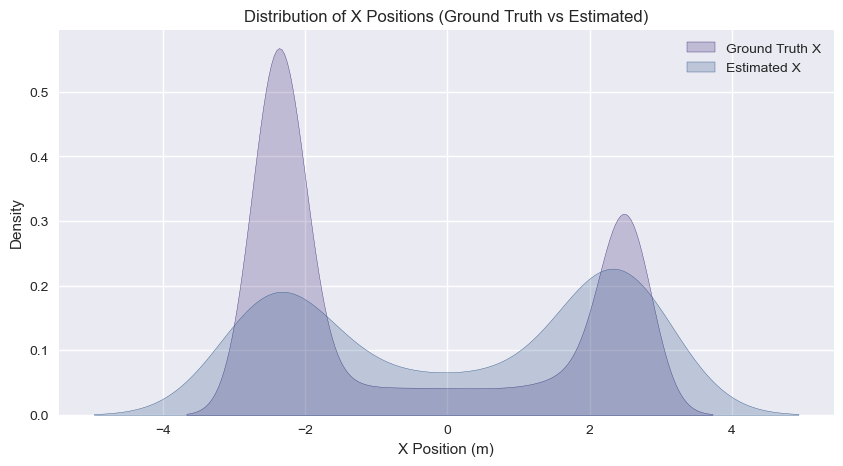

In [31]:
# --- Quick Visualization: Pose Distributions ---
import seaborn as sns 
plt.figure(figsize=(10, 5))
sns.kdeplot(df_subset['position.x'], label='Ground Truth X', fill=True)
sns.kdeplot(df_subset['pose.pose.position.x'], label='Estimated X', fill=True)
plt.title("Distribution of X Positions (Ground Truth vs Estimated)")
plt.xlabel("X Position (m)")
plt.legend()
plt.grid(True)
plt.show()

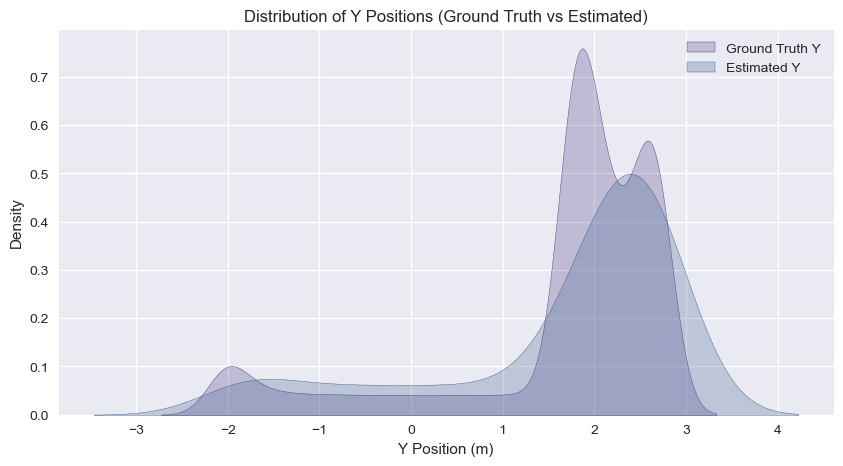

In [32]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df_subset['position.y'], label='Ground Truth Y', fill=True)
sns.kdeplot(df_subset['pose.pose.position.y'], label='Estimated Y', fill=True)
plt.title("Distribution of Y Positions (Ground Truth vs Estimated)")
plt.xlabel("Y Position (m)")
plt.legend()
plt.grid(True)
plt.show()
